# Bengaluru House Price Prediction

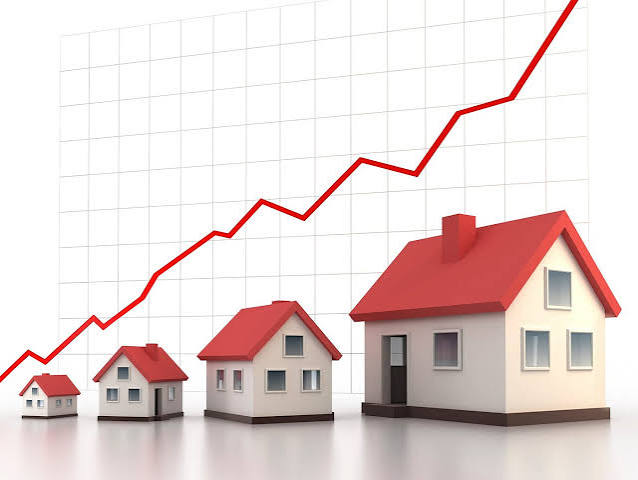

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Bengaluru_House_Data.csv')

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [5]:
df.shape

(13320, 9)

In [6]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(529)

In [8]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [10]:
df.nunique()

area_type          4
availability      81
location        1305
size              31
society         2688
total_sqft      2117
bath              19
balcony            4
price           1994
dtype: int64

In [11]:
df=df.drop_duplicates()

In [12]:
df.describe()

,bath,balcony,price
count,12718.000000,12186.000000,12791.000000
mean,2.708602,1.582308,114.317646
std,1.357764,0.822536,151.480310
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,73.000000
75%,3.000000,2.000000,121.000000
max,40.000000,3.000000,3600.000000


In [13]:
print("Unique values in categorical columns:")
print("area_type   :", df['area_type'].nunique())
print("availability:", df['availability'].nunique())
print("location    :", df['location'].nunique())
print("size        :", df['size'].nunique())
print("society     :", df['society'].nunique())

Unique values in categorical columns:
area_type   : 4
availability: 81
location    : 1305
size        : 31
society     : 2688


In [14]:
df = df.drop('society', axis = 1)

In [15]:
df.isnull().sum()

area_type         0
availability      0
location          1
size             16
total_sqft        0
bath             73
balcony         605
price             0
dtype: int64

In [16]:
df["size"] = df["size"].fillna(df["size"].mode()[0])

In [17]:
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [18]:
df["bath"] = df["bath"].fillna(df["bath"].median())

In [19]:
df=df.dropna()

In [20]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [21]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['area_type', 'availability', 'location', 'size', 'total_sqft'], dtype='object')

Numerical type columns:
Index(['bath', 'balcony', 'price'], dtype='object')


In [22]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

In [23]:
def convert_sqft_to_num(x):
    try:
        if '-' in str(x):
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [24]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['area_type', 'availability', 'location', 'size'], dtype='object')

Numerical type columns:
Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk'], dtype='object')


In [30]:
df.duplicated().sum()

np.int64(41)

In [31]:
41

41

In [32]:
df=df.drop_duplicates()

In [33]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 15:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [34]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [35]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: ['area_type']
Non-Categorical Features: ['availability', 'location', 'size']
Discrete Features: ['balcony']
Continuous Features: ['total_sqft', 'bath', 'price', 'bhk']


In [36]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

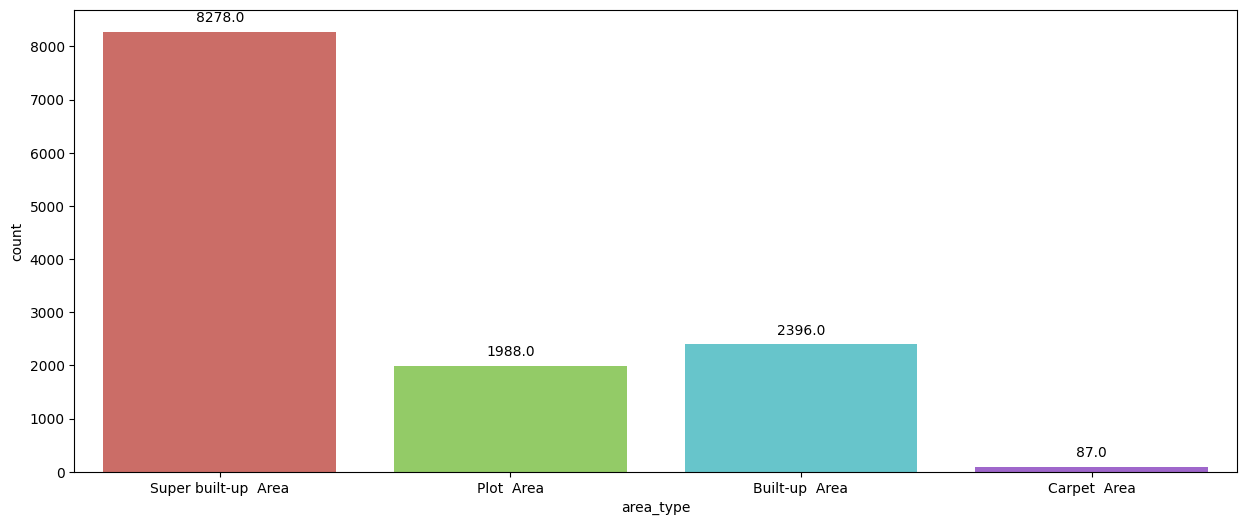

In [38]:
for i in categorical:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
    plt.show()

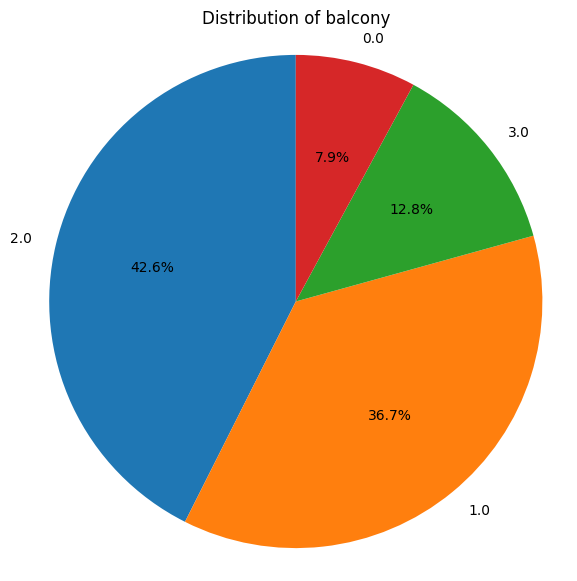

In [40]:
for i in discrete:
    counts = df[i].value_counts()
    
    plt.figure(figsize=(7, 7))
    plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Distribution of {i}')
    plt.axis('equal')
    plt.show()

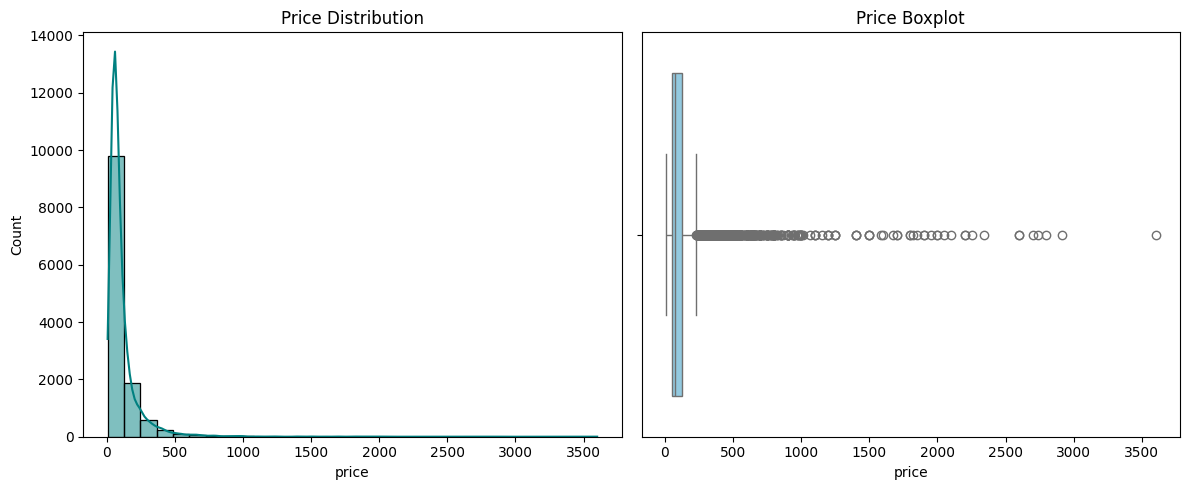

Price Skewness: 7.945


In [41]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='teal', bins=30)
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Price Boxplot')

plt.tight_layout()
plt.show()

print("Price Skewness:", round(df['price'].skew(), 3))

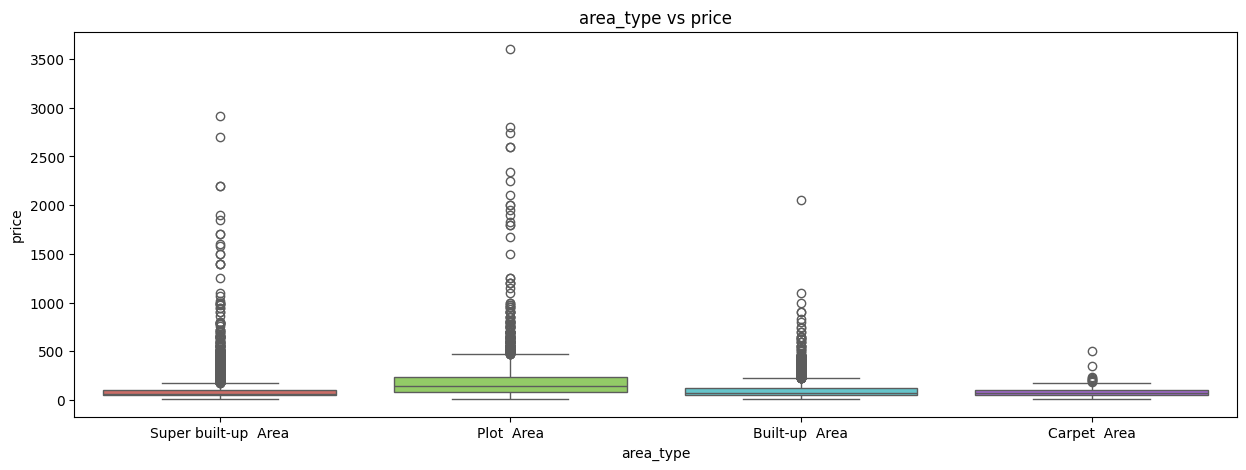

In [42]:
plt.figure(figsize=(15, 5))
sns.boxplot(x='area_type', y='price', data=df, palette='hls')
plt.title('area_type vs price')
plt.show()

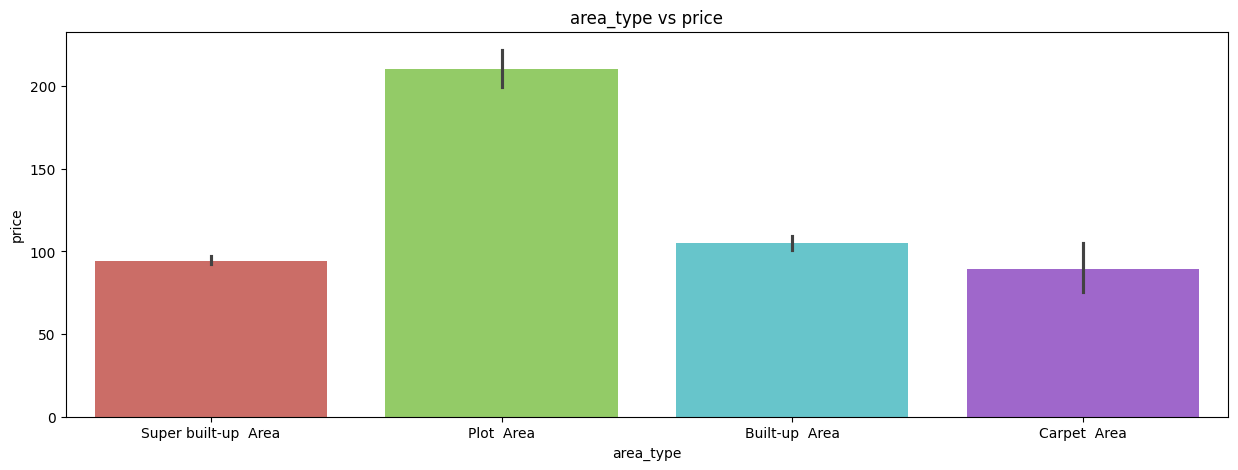

In [43]:
plt.figure(figsize=(15, 5))
sns.barplot(x='area_type', y='price', data=df, palette='hls')
plt.title('area_type vs price')
plt.show()

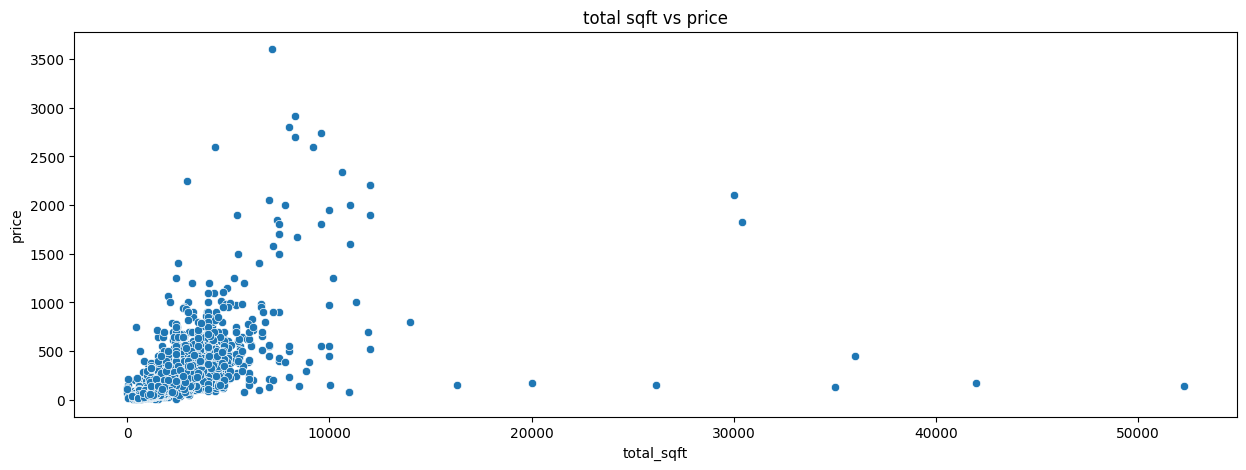

In [44]:
plt.figure(figsize=(15, 5))
sns.scatterplot(x='total_sqft', y='price', data=df, palette='hls')
plt.title('total sqft vs price')
plt.show()

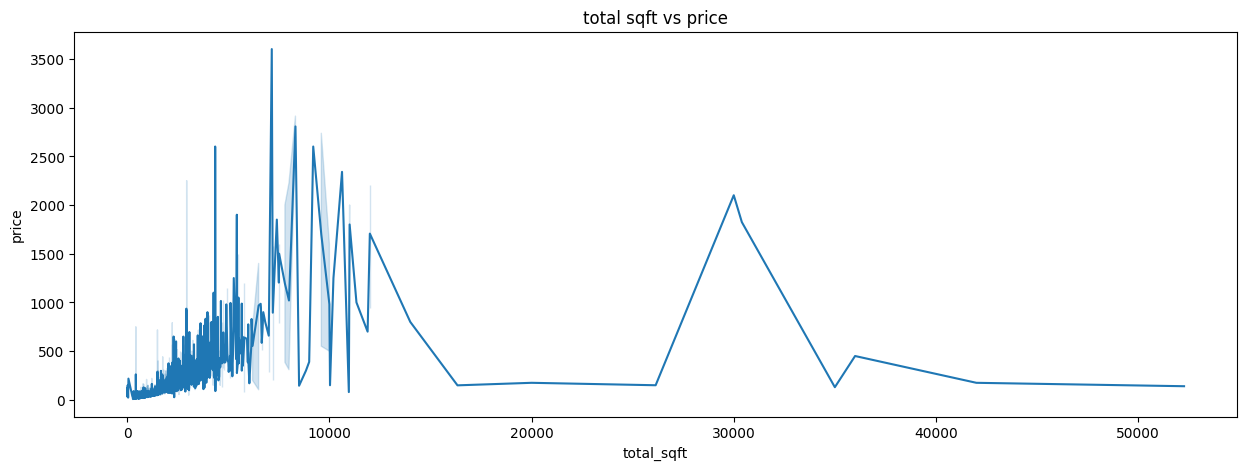

In [45]:
plt.figure(figsize=(15, 5))
sns.lineplot(x='total_sqft', y='price', data=df, palette='hls')
plt.title('total sqft vs price')
plt.show()

In [46]:
df.nunique()

area_type          4
availability      81
location        1305
size              31
total_sqft      1999
bath              19
balcony            4
price           1994
bhk               19
dtype: int64

In [47]:
df=df.drop('availability',axis=1)

In [48]:
df

,area_type,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Green Glen Layout,3 BHK,1715.0,3.0,3.0,112.00,3
13315,Built-up Area,Whitefield,5 Bedroom,3453.0,4.0,0.0,231.00,5
13316,Super built-up Area,Richards Town,4 BHK,3600.0,5.0,2.0,400.00,4
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,1.0,60.00,2


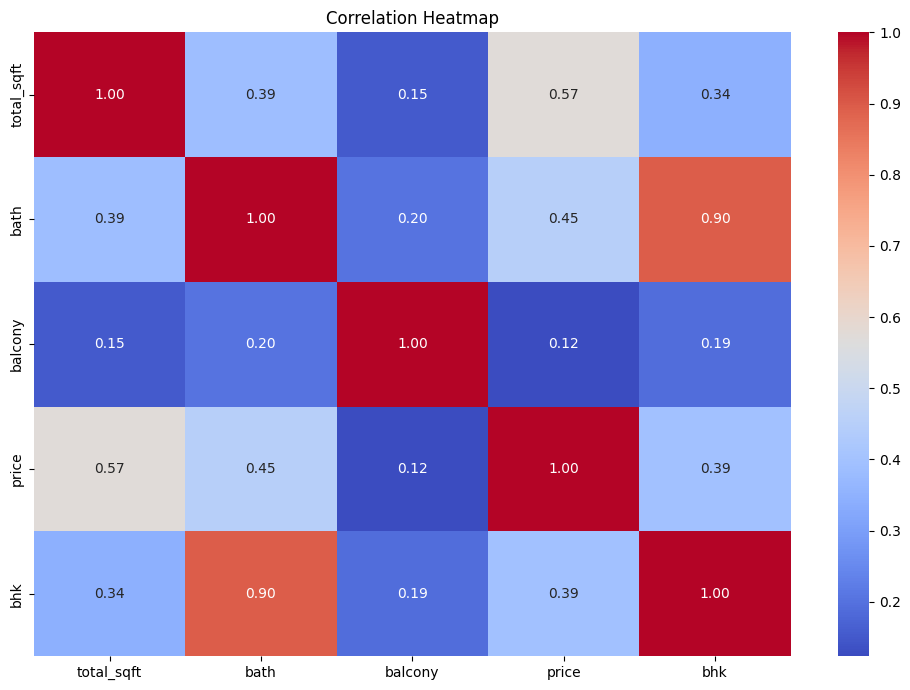

In [49]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [50]:
df

,area_type,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Green Glen Layout,3 BHK,1715.0,3.0,3.0,112.00,3
13315,Built-up Area,Whitefield,5 Bedroom,3453.0,4.0,0.0,231.00,5
13316,Super built-up Area,Richards Town,4 BHK,3600.0,5.0,2.0,400.00,4
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,1.0,60.00,2


In [51]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'total_sqft',
    'bath',
    'balcony',
    'price',
    'bhk'
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,area_type,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,2 BHK,-0.407952,-0.520812,-0.745178,-0.497253,-0.623545
1,Plot Area,Chikka Tirupathi,4 Bedroom,0.815906,1.690746,1.728851,0.036297,0.899945
2,Built-up Area,Uttarahalli,3 BHK,-0.103573,-0.520812,1.728851,-0.346081,0.138200
3,Super built-up Area,Lingadheeranahalli,3 BHK,-0.039368,0.216374,-0.745178,-0.128521,0.138200
4,Super built-up Area,Kothanur,2 BHK,-0.293810,-0.520812,-0.745178,-0.418601,-0.623545


In [52]:
cat_cols = ['area_type', 'location']

for col in cat_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(col, axis=1)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (12749, 1315)


,size,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,2 BHK,-0.407952,-0.520812,-0.745178,-0.497253,-0.623545,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,4 Bedroom,0.815906,1.690746,1.728851,0.036297,0.899945,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3 BHK,-0.103573,-0.520812,1.728851,-0.346081,0.138200,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3 BHK,-0.039368,0.216374,-0.745178,-0.128521,0.138200,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2 BHK,-0.293810,-0.520812,-0.745178,-0.418601,-0.623545,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [55]:
df.isnull().sum()

size                              0
total_sqft                       45
bath                              0
balcony                           0
price                             0
                                 ..
location_t.c palya                0
location_tc.palya                 0
location_vinayakanagar            0
location_white field,kadugodi     0
location_whitefiled               0
Length: 1315, dtype: int64

In [57]:
df=df.dropna()

In [59]:
df

,size,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,2 BHK,-0.407952,-0.520812,-0.745178,-0.497253,-0.623545,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,4 Bedroom,0.815906,1.690746,1.728851,0.036297,0.899945,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3 BHK,-0.103573,-0.520812,1.728851,-0.346081,0.138200,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3 BHK,-0.039368,0.216374,-0.745178,-0.128521,0.138200,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2 BHK,-0.293810,-0.520812,-0.745178,-0.418601,-0.623545,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314,3 BHK,0.114407,0.216374,1.728851,-0.016445,0.138200,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
13315,5 Bedroom,1.492039,0.953560,-1.982192,0.768090,1.661690,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13316,4 BHK,1.608560,1.690746,0.491837,1.882262,0.899945,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
13317,2 BHK,-0.340577,-0.520812,-0.745178,-0.359267,-0.623545,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [65]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10163, 1314)
X_test : (2541, 1314)
y_train: (10163,)
y_test : (2541,)


In [66]:
model = LinearRegression()

In [70]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# ==============================
# CREATE BHK ONLY IF SIZE EXISTS
# ==============================

if 'size' in df.columns:
    df['bhk'] = pd.to_numeric(
        df['size'].astype(str).str.extract(r'(\d+)')[0],
        errors='coerce'
    )
    df.drop('size', axis=1, inplace=True)

elif 'bhk' not in df.columns:
    print("Neither 'size' nor 'bhk' exists in the current DataFrame.")
    
print("Columns:", df.columns.tolist())


# ==============================
# CONVERT TOTAL_SQFT
# ==============================

def convert_sqft_to_num(x):
    try:
        if '-' in str(x):
            values = str(x).split('-')
            return (float(values[0]) + float(values[1])) / 2
        return float(x)
    except:
        return np.nan

if 'total_sqft' in df.columns:
    df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)


# ==============================
# REMOVE UNNECESSARY COLUMNS
# ==============================

df.drop('society', axis=1, inplace=True, errors='ignore')


# ==============================
# FILL MISSING VALUES
# ==============================

if 'location' in df.columns:
    df['location'] = df['location'].fillna(
        df['location'].mode()[0]
    )

for col in ['bhk', 'bath', 'balcony', 'total_sqft']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


# ==============================
# ENCODE LOCATION
# ==============================

if 'location' in df.columns:
    df = pd.get_dummies(
        df,
        columns=['location'],
        drop_first=True,
        dtype=int
    )


# ==============================
# REMOVE REMAINING MISSING VALUES
# ==============================

df = df.dropna()


# ==============================
# CREATE X AND y
# ==============================

X = df.drop('price', axis=1)
y = df['price']


# ==============================
# CHECK FOR TEXT COLUMNS
# ==============================

print("\nText columns remaining:")
print(X.select_dtypes(include='object').columns)


# ==============================
# TRAIN-TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==============================
# MODEL
# ==============================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel trained successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Columns: ['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'area_type_Built-up  Area', 'area_type_Carpet  Area', 'area_type_Plot  Area', 'area_type_Super built-up  Area', 'location_ Anekal', 'location_ Banaswadi', 'location_ Basavangudi', 'location_ Bhoganhalli', 'location_ Devarabeesana Halli', 'location_ Devarachikkanahalli', 'location_ Electronic City', 'location_ Mysore Highway', 'location_ Rachenahalli', 'location_ Sector 1 HSR Layout', 'location_ Thanisandra', 'location_ Whitefield', 'location_ ittamadu', 'location_ south', 'location_1 Annasandrapalya', 'location_1 Giri Nagar', 'location_1 Immadihalli', 'location_1 Ramamurthy Nagar', 'location_12th cross srinivas nagar banshankari 3rd stage', 'location_1A Block Koramangala', 'location_1Channasandra', 'location_1Hanuman Nagar', 'location_1Hoysalanagar', 'location_1Kasavanhalli', 'location_1st Block BEL Layout', 'location_1st Block HBR Layout', 'location_1st Block HRBR Layout', 'location_1st Block Jayanagar', 'location_1st Block Ko

In [71]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [74]:
y_pred = model.predict(X_test)

In [75]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

In [76]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'total_sqft',
    'bath',
    'balcony',
    'price',
    'bhk'
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_ Anekal,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,-0.141505,-0.520623,-0.746924,-0.496184,-0.623998,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0.372419,1.695120,1.728339,0.036991,0.902825,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.141505,-0.520623,1.728339,-0.345119,0.139414,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.141505,0.217958,-0.746924,-0.127712,0.139414,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.141505,-0.520623,-0.746924,-0.417588,-0.623998,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
